## Summary of paper relevant analysis results

1. Probit
- subjets without any evidence for taking ratio into account (no slope!)
    * model-1 (both formats): 46, 50
    * model-2 symbolic: 40,46

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
import os
import bambi
import arviz as az

bids_folder = '/Volumes/g_econ_department$/projects/2023/renkert_dehollander_ruff_dnumr/data/ds-dnumrisk'  # 
trace_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')

from numrisk.behavior_risk.utils import get_data
df = get_data()
df['x'] = df['log(risky/safe)']

subList = df.index.unique('subject')
groupList = pd.DataFrame(df[['group']].groupby('subject').mean()).astype(int)

number of subjects in dataframe: 66
Int64Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
            18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
            35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
            52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
           dtype='int64', name='subject')


In [ ]:
model_label =  1 # 'chose_risky ~ x + x*group*format + (x*format|subject)'
format = 'both' 
traces = az.from_netcdf( op.join(trace_folder, f'rnp_model-{model_label}_format-{format}_trace.netcdf'))
model = bambi.Model('chose_risky ~ x + x*group*format + (x*format|subject)', link='probit', family='bernoulli', data=df.reset_index())


In [ ]:
from numrisk.behavior_risk.utils import extract_rnp_precision

intercept, gamma = extract_rnp_precision(traces, model, df, group_level = False) # format=False, even though n_safe not regressor, posteriors exaclty the same across differnt n_safe

In [42]:
# identify subjects with low precision - no evidence for gamma being different from 0
# test if 0.95  (alpha of 0.1 - one sided) of samples are larger than 0 
print(f'format = {format}')

alpha = 0.001
for sub in subList:
    group_assinment = groupList.loc[sub, 'group']
    tmp_sub = gamma.xs(sub, level='subject').xs(group_assinment, level='group').unstack('format').unstack('n_safe')
    if (tmp_sub.values > 0).mean() < (1 - alpha):
        print(f"Subject {sub} has low precision")


format = both
Subject 40 has low precision
Subject 46 has low precision
Subject 45 has low precision
Subject 32 has low precision
Subject 50 has low precision


In [37]:
# same as based on MAPS : get subjects where gamma is smaller than 1

gamma_maps = pd.DataFrame(gamma.groupby('subject').mean().mean(axis=1), columns=['gamma'])
gamma_maps[gamma_maps['gamma'] < 1]

,gamma
subject,
32,0.752141
40,0.847747
45,0.999594
46,0.389493
50,0.669236


# model - 0 - basic without group!

In [56]:
bids_folder = '/Users/mrenke/data/ds-dnumrisk'
trace_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')


model_label =  0 # 'chose_risky ~ x + x*group*format + (x*format|subject)'
format = 'both' 
trace = az.from_netcdf( op.join(trace_folder, f'rnp_model-{model_label}_format-{format}_trace.netcdf'))
model = bambi.Model('chose_risky ~ x + x*format + (x*format|subject)', link='probit', family='bernoulli', data=df.reset_index())

fake_data = pd.MultiIndex.from_product([df.reset_index()['subject'].unique(),[0,1],df.reset_index()['format'].unique()],
                                    names=['subject', 'x', 'format']).to_frame().reset_index(drop=True)
pred = model.predict(trace, 'mean', fake_data, inplace=False)['posterior']['chose_risky_mean']
pred = pred.to_dataframe().unstack([0, 1])
pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

# return pred

pred0 = pred.xs(0, 0, 'x')
from numrisk.behavior_risk.utils import invprobit
intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

In [58]:
print(f'format = {format}')

alpha = 0.001
for sub in subList:
    group_assinment = groupList.loc[sub, 'group']
    tmp_sub = gamma.xs(sub, level='subject').unstack('format')
    if (tmp_sub.values > 0).mean() < (1 - alpha):
        print(f"Subject {sub} has low precision")

format = both
Subject 40 has low precision
Subject 46 has low precision
Subject 45 has low precision
Subject 32 has low precision
Subject 50 has low precision


<Axes: ylabel='Count'>

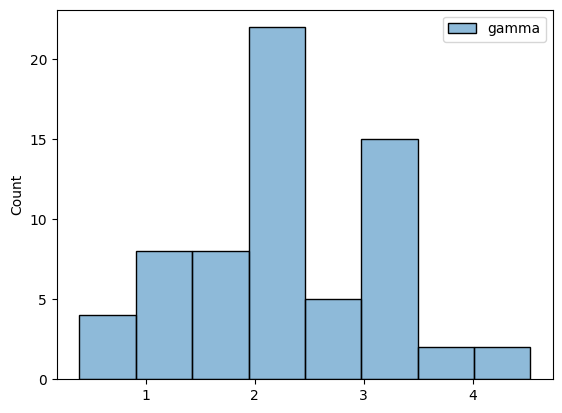

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

gamma_maps = pd.DataFrame(gamma.groupby('subject').mean().mean(axis=1), columns=['gamma'])
sns.histplot(gamma_maps)
